In [1]:
import pandas as pd

ai = pd.read_pickle('../.data/derwent/ai/ai_patents.pkl')
ai = ai[['assignee', 'publication_number','backward_citations']]
ai = ai[ai.backward_citations.notnull()].reset_index(drop=True)
ai.assignee = ai.assignee.map(lambda x: x.removesuffix(',,,,'))
ai

,assignee,publication_number,backward_citations
0,BETH ISRAEL DEACONESS MEDICAL CENT,AU2006283101A1,[WO2005028625A2]
1,BETH ISRAEL DEACONESS MEDICAL CENT,AU2006283101B2,[WO2005028625A2]
2,CROWN EQUIP CORP,AU2012302046A1,"[US20040193363A1, US20110071718A1, US200600897..."
3,CROWN EQUIP CORP,AU2012302046A8,"[US20110071718A1, US20060089765A1, US200401933..."
4,CROWN EQUIP CORP,AU2012302046B2,"[US20110071718A1, US20060089765A1, US200401933..."
...,...,...,...
127048,IND TECHNOLOGY RES INST,TWI607387B,"[TWI221587B, US20140363074A1, TWI221587A, TW20..."
127049,KNERON INC,TWI607389B,"[CN106250863A, CN106203619A, CN106228240A]"
127050,IND TECHNOLOGY RES INST,TWI607412B,"[TW201346833A, TW201624326A, US20130249901A1, ..."
127051,IND TECHNOLOGY RES INST,TWI608369B,"[TW200844429A, TWI456190B, TWI456190A, WO20160..."


In [2]:
ai = ai.explode('backward_citations')

n = ai.shape[0]
while True:
    ai = ai[ai.backward_citations.isin(ai.publication_number)]
    if ai.shape[0] == n:
        break
    else:
        n = ai.shape[0]
ai.reset_index(drop=True, inplace=True)
ai

,assignee,publication_number,backward_citations
0,CROWN EQUIP CORP,AU2012302046A1,US20110071718A1
1,CROWN EQUIP CORP,AU2012302046A8,US20110071718A1
2,CROWN EQUIP CORP,AU2012302046B2,US20110071718A1
3,ADOBE CO LTD,AU2016256753A1,US20170011279A1
4,MICROSOFT CORP,CN102737104A,US20100205180A1
...,...,...,...
70563,UNIV NAT CHAO TUNG,TWI539388B,CN104523268A
70564,UNIV NAT CHIN YI TECHNOLOGY,TWI581195B,US8840562B2
70565,WINBOND ELECTRONICS CORP,TWI598829B,US8374974B2
70566,KNERON INC,TWI607389B,CN106203619A


In [3]:
assignee_map = {pn: name for pn, name in zip(ai.publication_number, ai.assignee)}
ai.backward_citations = ai.backward_citations.map(lambda x: assignee_map[x])
ai = ai[ai.assignee != ai.backward_citations]
ai

,assignee,publication_number,backward_citations
0,CROWN EQUIP CORP,AU2012302046A1,DEERE & CO
1,CROWN EQUIP CORP,AU2012302046A8,DEERE & CO
2,CROWN EQUIP CORP,AU2012302046B2,DEERE & CO
3,ADOBE CO LTD,AU2016256753A1,XEROX CORP
4,MICROSOFT CORP,CN102737104A,ORACLE INT CORP
...,...,...,...
70563,UNIV NAT CHAO TUNG,TWI539388B,UNIV JIANGNAN
70564,UNIV NAT CHIN YI TECHNOLOGY,TWI581195B,COVIDIEN LP
70565,WINBOND ELECTRONICS CORP,TWI598829B,HALLIBURTON ENERGY SERVICES INC
70566,KNERON INC,TWI607389B,SAMSUNG ELECTRONICS CO LTD


In [4]:
edges = ai.apply(lambda x: (x.assignee, x.backward_citations), axis=1).unique()
edges

array([('CROWN EQUIP CORP', 'DEERE & CO'), ('ADOBE CO LTD', 'XEROX CORP'),
       ('MICROSOFT CORP', 'ORACLE INT CORP'), ...,
       ('UNIV NAT CHIN YI TECHNOLOGY', 'COVIDIEN LP'),
       ('KNERON INC', 'SAMSUNG ELECTRONICS CO LTD'),
       ('IND TECHNOLOGY RES INST', 'ADOBE SYSTEMS INC')], dtype=object)

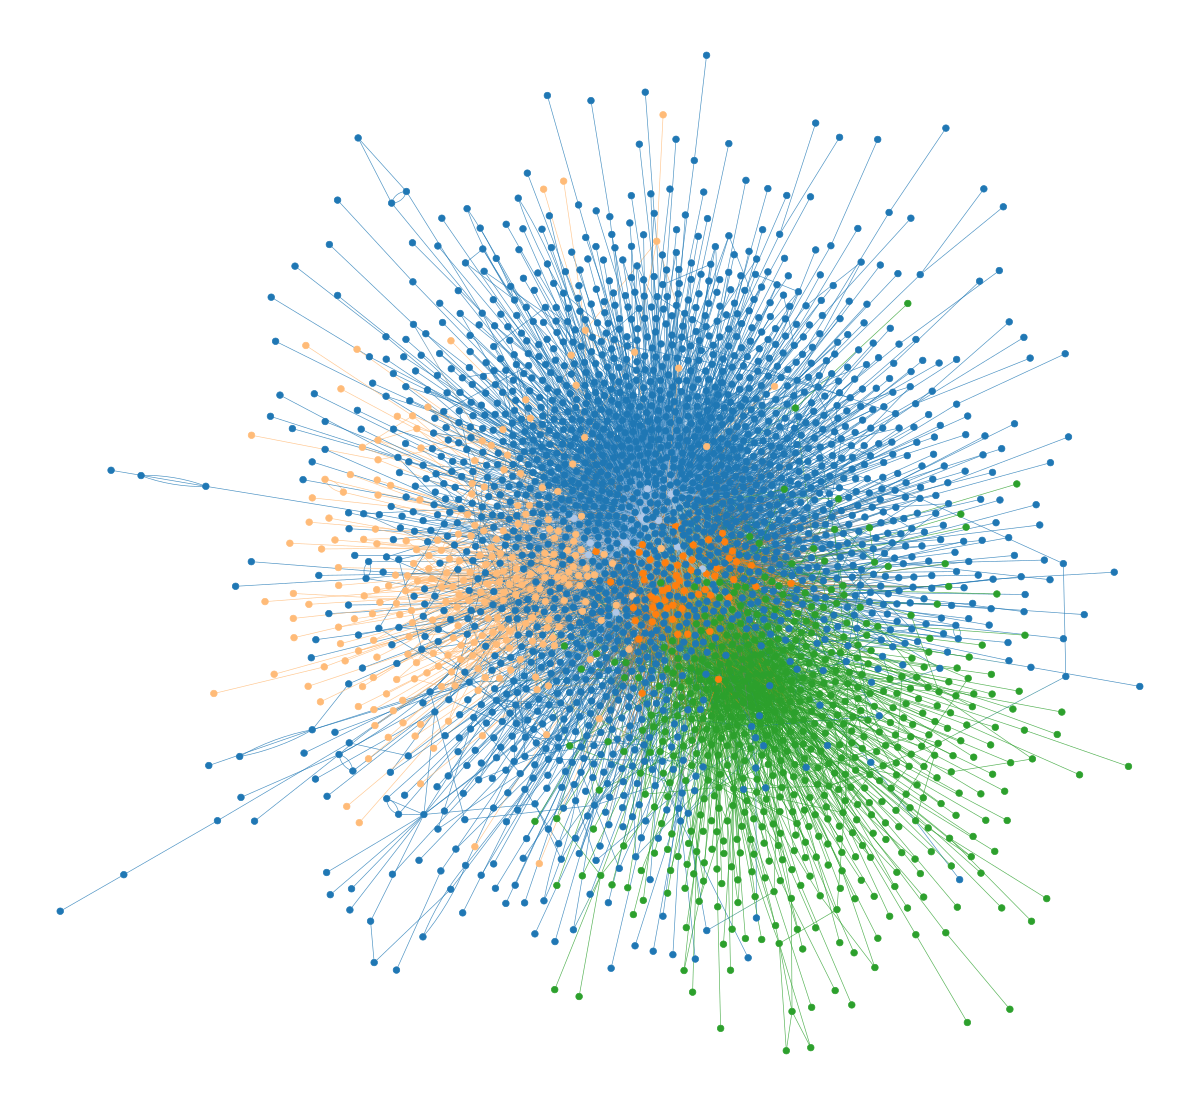

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fb82a669dc0, at 0x7fb66d18efc0>

In [5]:
import graph_tool.all as gt

G = gt.Graph(list(edges), hashed=True, directed=False)
G = gt.extract_largest_component(G)
sbm = gt.minimize_blockmodel_dl(G)

sbm.draw()

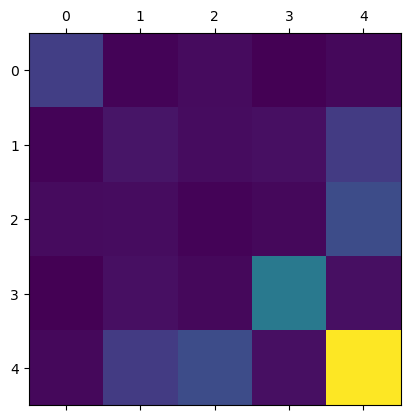

In [6]:
from matplotlib.pyplot import matshow

state = sbm.copy(b=gt.contiguous_map(sbm.get_blocks()))
e = state.get_matrix()
B = state.get_nonempty_B()
matshow(e.todense()[:B, :B])

In [9]:
sbm.get_matrix()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25 stored elements and shape (2717, 2717)>